<a href="https://colab.research.google.com/github/Maanvijangir/Github-demo/blob/main/plant_village_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing dataset from Colab and mounting to drive

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\r\n  "username" : "maanvijangir",\r\n  "key" : "KGAT_fe15e274164d1eef4d46da385bf0fc7f"\r\n}'}

In [ ]:
import os
os.makedirs('/root/.kaggle',exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json


In [ ]:
!pip install kaggle

In [ ]:
!kaggle datasets download -d moazawadali/plantvillage-tomato -p /content/drive/MyDrive/


Dataset URL: https://www.kaggle.com/datasets/moazawadali/plantvillage-tomato
License(s): DbCL-1.0
plantvillage-tomato.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip /content/drive/MyDrive/plantvillage-tomato.zip -d /content/drive/MyDrive/

Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/PlantVillage/train/Tomato___Tomato_Yellow_Leaf_Curl_Virus/9cfa3f33-36c3-4812-9d23-73898c39d8db___UF.GRC_YLCV_Lab 01362.JPG  
  inflating: /content/drive/MyDrive/PlantVillage/train/Tomato___Tomato_Yellow_Leaf_Curl_Virus/9d00f458-5616-470e-a8ad-9694c01999bb___YLCV_NREC 2276.JPG  
  inflating: /content/drive/MyDrive/PlantVillage/train/Tomato___Tomato_Yellow_Leaf_Curl_Virus/9d032375-b1ce-45ca-a067-e699486d511d___YLCV_GCREC 2220.JPG  
  inflating: /content/drive/MyDrive/PlantVillage/train/Tomato___Tomato_Yellow_Leaf_Curl_Virus/9d101a85-6847-4e83-87bc-63f0794f0032___YLCV_GCREC 2763.JPG  
  inflating: /content/drive/MyDrive/PlantVillage/train/Tomato___Tomato_Yellow_Leaf_Curl_Virus/9d1f2f28-34e4-45ca-9517-e9410054ba5f___YLCV_GCREC 2503.JPG  
  inflating: /content/drive/MyDrive/PlantVillage/train/Tomato___Tomato_Yellow_Leaf_Curl_Virus/9d220ab4-26b6-4367-956b-59b625501152___YLCV_NREC 2600.JPG  
  inflating: /c

In [ ]:
import os
print(os.listdir("/content/drive/MyDrive/PlantVillage"))

['test', 'train', 'val']


locating data locally on colab

In [1]:
!cp /content/drive/MyDrive/plantvillage-tomato.zip /content/dataset.zip
!unzip -q /content/dataset.zip -d /content/unzipped_plantvillage_data
!rm /content/dataset.zip

# **BASIC CNN MODEL**

# Importing Libraries

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Data Preprocessing

In [ ]:
training_set = tf.keras.utils.image_dataset_from_directory(
    '/content/unzipped_plantvillage_data/PlantVillage/train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(64,64),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)


Found 14523 files belonging to 10 classes.


In [ ]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    '/content/unzipped_plantvillage_data/PlantVillage/val',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(64,64),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)



Found 1812 files belonging to 10 classes.


In [ ]:
for x,y in training_set:
  print(x,x.shape)
  print(y,y.shape)
  break

tf.Tensor(
[[[[108.5  109.5  103.5 ]
   [109.75 110.75 104.75]
   [108.75 109.75 103.75]
   ...
   [ 87.25  87.25  87.25]
   [ 80.5   80.5   80.5 ]
   [ 75.5   75.5   75.5 ]]

  [[101.75 102.75  96.75]
   [108.25 109.25 103.25]
   [109.   110.   104.  ]
   ...
   [ 81.75  81.75  81.75]
   [ 81.    81.    81.  ]
   [ 78.    78.    78.  ]]

  [[106.   107.   101.  ]
   [105.5  106.5  100.5 ]
   [103.25 104.25  98.25]
   ...
   [ 82.    82.    82.  ]
   [ 85.75  85.75  85.75]
   [ 84.5   84.5   84.5 ]]

  ...

  [[142.   147.   140.  ]
   [142.25 147.25 140.25]
   [143.25 148.25 141.25]
   ...
   [124.25 128.25 127.25]
   [123.75 127.75 126.75]
   [122.   126.   125.  ]]

  [[139.   144.   137.  ]
   [139.75 144.75 137.75]
   [140.75 145.75 138.75]
   ...
   [127.5  131.5  130.5 ]
   [125.75 129.75 128.75]
   [124.   128.   127.  ]]

  [[142.   147.   140.  ]
   [141.5  146.5  139.5 ]
   [140.5  145.5  138.5 ]
   ...
   [127.75 131.75 130.75]
   [127.25 131.25 130.25]
   [126.25 130.25 12

# Building model

In [ ]:
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.models import Sequential

In [ ]:
num_classes = len(training_set.class_names) #auto-detects classes
num_classes

10

In [ ]:
from tensorflow.keras import layers
data_augmentation = Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])


In [ ]:
model=Sequential([
    data_augmentation,
    Conv2D(16,3,padding='same',activation='relu',input_shape=(64,64,3)),
    Conv2D(16,3,padding='same',activation='relu'),
    MaxPooling2D(pool_size=2, strides=2),

    Conv2D(32, 3, padding='same', activation='relu'),
    Conv2D(32, 3, padding='same', activation='relu'),
    MaxPooling2D(pool_size=2, strides=2),

    Conv2D(64, 3, padding='same', activation='relu'),
    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D(pool_size=2, strides=2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 64, 64, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 597,786 (2.28 MB)

 Trainable params: 597,786 (2.28 MB)

 Non-trainable params: 0 (0.00 B)

# Compiling Model

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))   #for checking that is GPU is active or not

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [ ]:
history = model.fit(training_set, validation_data=validation_set, epochs=10)

Epoch 1/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 24s 36ms/step - accuracy: 0.4759 - loss: 1.6939 - val_accuracy: 0.5618 - val_loss: 1.2327
Epoch 2/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.6493 - loss: 1.0297 - val_accuracy: 0.5977 - val_loss: 1.2443
Epoch 3/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.7132 - loss: 0.8099 - val_accuracy: 0.6468 - val_loss: 1.1114
Epoch 4/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.7587 - loss: 0.6877 - val_accuracy: 0.6838 - val_loss: 1.0101
Epoch 5/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.7942 - loss: 0.5892 - val_accuracy: 0.6810 - val_loss: 1.0922
Epoch 6/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.8137 - loss: 0.5276 - val_accuracy: 0.7064 - val_loss: 0.9759
Epoch 7/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.8311 - loss: 0.4832 - val_accuracy: 0.7417 - val_loss: 0.8259
Epoch 8/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.8405 - loss: 0.4518 - 

In [ ]:
model.save("/content/drive/MyDrive/tomato_model_augmented.keras")

In [ ]:
history.history

{'accuracy': [0.4758658707141876,
  0.6493148803710938,
  0.7132135033607483,
  0.7586587071418762,
  0.7941884994506836,
  0.8137437105178833,
  0.8310955166816711,
  0.8405288457870483,
  0.8599463105201721,
  0.8640776872634888],
 'loss': [1.693906307220459,
  1.0297468900680542,
  0.8098732233047485,
  0.6877403259277344,
  0.589194118976593,
  0.5276341438293457,
  0.48316943645477295,
  0.45183035731315613,
  0.40356874465942383,
  0.3918990194797516],
 'val_accuracy': [0.5618101358413696,
  0.5976821184158325,
  0.6467990875244141,
  0.6837748289108276,
  0.6810154318809509,
  0.7064017653465271,
  0.7417218685150146,
  0.7522075176239014,
  0.817328929901123,
  0.8211920261383057],
 'val_loss': [1.2326581478118896,
  1.2443265914916992,
  1.1114333868026733,
  1.010054588317871,
  1.0922045707702637,
  0.9758628606796265,
  0.8259073495864868,
  0.7917677760124207,
  0.5401501059532166,
  0.5676635503768921]}

In [ ]:
import json
import os
with open("/content/drive/MyDrive/history.json", "w") as f:
    json.dump(history.history, f)

In [ ]:
train_loss, train_acc = model.evaluate(training_set)

454/454 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.8159 - loss: 0.5657


In [ ]:
print(train_loss,train_acc)

0.5656956434249878 0.8158782720565796


In [ ]:
val_loss, val_acc = model.evaluate(validation_set)

57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.8212 - loss: 0.5677


In [ ]:
print(val_loss,val_acc)

0.5676635503768921 0.8211920261383057


In [ ]:
class_name = validation_set.class_names
class_name

['Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

In [ ]:
test_set = tf.keras.utils.image_dataset_from_directory(
    '/content/unzipped_plantvillage_data/PlantVillage/test',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(64, 64),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 1825 files belonging to 10 classes.


In [ ]:
y_pred = model.predict(test_set)
y_pred,y_pred.shape

58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step


(array([[6.75117314e-01, 2.68381566e-01, 7.84280943e-04, ...,
         1.03439623e-03, 4.06207300e-06, 7.37581232e-08],
        [9.93839443e-01, 5.83738415e-03, 4.04816783e-05, ...,
         1.15655952e-04, 2.07638906e-09, 7.35211725e-10],
        [9.36317503e-01, 4.70407819e-03, 3.91170382e-03, ...,
         1.72573375e-04, 8.75241710e-07, 4.66649595e-07],
        ...,
        [1.06514198e-14, 7.62644448e-10, 3.78441200e-06, ...,
         5.53345957e-14, 7.02971126e-10, 9.99989629e-01],
        [1.13621468e-09, 1.29010195e-05, 4.58396134e-05, ...,
         4.27871377e-10, 4.41197153e-06, 9.40415502e-01],
        [6.63873460e-03, 1.12822857e-02, 2.44416539e-02, ...,
         1.91744522e-03, 7.64348311e-04, 9.36736345e-01]], dtype=float32),
 (1825, 10))

In [ ]:
predicted_categories = tf.argmax(y_pred, axis=1)
predicted_categories,predicted_categories.shape

(<tf.Tensor: shape=(1825,), dtype=int64, numpy=array([0, 0, 0, ..., 9, 9, 9])>,
 TensorShape([1825]))

In [ ]:
true_categories = tf.concat([y for x,y in test_set],axis=0)
true_categories,true_categories.shape


(<tf.Tensor: shape=(1825, 10), dtype=float32, numpy=
 array([[1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>,
 TensorShape([1825, 10]))

In [ ]:
y_true = tf.argmax(true_categories, axis=1)
y_true,y_true.shape

(<tf.Tensor: shape=(1825,), dtype=int64, numpy=array([0, 0, 0, ..., 9, 9, 9])>,
 TensorShape([1825]))

**Precision** -> How reliable predictions are for each class.
**Recall** -> How well the model captures all true cases of a class.
**F1-score** -> Balance between precision and recall.

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_true,predicted_categories,target_names=class_name))

                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.90      0.87      0.89       214
                        Tomato___Early_blight       0.66      0.80      0.72       100
                         Tomato___Late_blight       0.85      0.78      0.81       192
                           Tomato___Leaf_Mold       0.96      0.53      0.68        96
                  Tomato___Septoria_leaf_spot       0.92      0.48      0.63       178
Tomato___Spider_mites Two-spotted_spider_mite       0.56      0.84      0.67       169
                         Tomato___Target_Spot       0.68      0.85      0.76       141
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.98      0.91      0.94       537
                 Tomato___Tomato_mosaic_virus       0.94      0.84      0.89        38
                             Tomato___healthy       0.75      0.99      0.86       160

                                     accu

In [ ]:
cm  = confusion_matrix(y_true,predicted_categories)
cm,cm.shape

(array([[186,   3,   3,   0,   1,   5,   6,   9,   0,   1],
        [  3,  80,   4,   0,   0,   5,   6,   1,   0,   1],
        [  6,  14, 150,   1,   0,  15,   0,   1,   0,   5],
        [  0,   8,   4,  51,   6,  23,   0,   0,   0,   4],
        [  2,  14,  15,   1,  85,  18,  19,   1,   1,  22],
        [  0,   0,   0,   0,   0, 142,  18,   0,   1,   8],
        [  0,   0,   0,   0,   0,  10, 120,   0,   0,  11],
        [  9,   2,   0,   0,   0,  36,   2, 488,   0,   0],
        [  0,   0,   0,   0,   0,   1,   5,   0,  32,   0],
        [  0,   0,   1,   0,   0,   0,   0,   0,   0, 159]]),
 (10, 10))

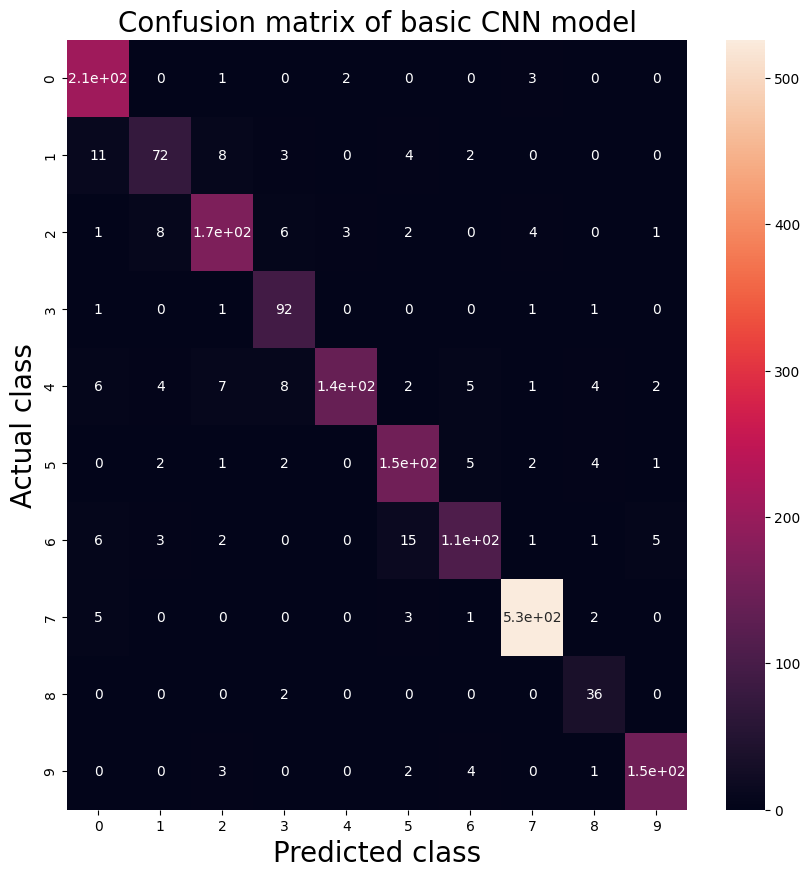

In [22]:
plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,annot_kws={'size':10})
plt.xlabel("Predicted class",fontsize=20)
plt.ylabel("Actual class",fontsize=20)
plt.title("Confusion matrix of basic CNN model",fontsize=20)
plt.show()

# **MobileNet**

# Importing libraries

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models

# Preprocessing Datasets

In [3]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

In [4]:
train_data = datasets.ImageFolder("/content/unzipped_plantvillage_data/PlantVillage/train",transform=transform)
val_data = datasets.ImageFolder("/content/unzipped_plantvillage_data/PlantVillage/val",transform=transform)
test_data = datasets.ImageFolder("/content/unzipped_plantvillage_data/PlantVillage/test",transform=transform)

In [5]:
train_loader = torch.utils.data.DataLoader(train_data,batch_size=16,shuffle=True)
val_loader = torch.utils.data.DataLoader(val_data,batch_size=16,shuffle=False)
test_loader = torch.utils.data.DataLoader(test_data,batch_size=16,shuffle=False)

# loading MobileNet_v2

In [6]:
model = models.mobilenet_v2(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 104MB/s] 


In [7]:
for param in model.features.parameters():
  param.requires_grad = False

In [8]:
num_classes = len(train_data.classes)
num_classes

10

In [9]:
model.classifier[1] = nn.Linear(model.classifier[1].in_features,num_classes)

# Train model

In [10]:
device = torch.device("cpu")
model= model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

In [12]:
for epoch in range(3):
  model.train()
  running_loss=0.0
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs,labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
  print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")
print("Training complete!")

Epoch 1, Loss: 0.47877916215717925
Epoch 2, Loss: 0.4558085704936199
Epoch 3, Loss: 0.438878013145195
Training complete!


evaluation of accuracy

In [13]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Validation Accuracy: {100 * correct / total:.2f}%")


Validation Accuracy: 91.17%


# save model for prediction

In [14]:
torch.save(model.state_dict(), "/content/drive/MyDrive/mobilenet_tomato.pth")

# Evaluation of the model

In [15]:
from sklearn.metrics import classification_report, confusion_matrix

In [16]:
model.eval()
all_preds=[]
all_labels=[]

with torch.no_grad():
  for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs,1)

    all_preds.extend(predicted.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

classification report

In [17]:
print(classification_report(all_labels, all_preds, target_names=test_data.classes))

                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.87      0.97      0.92       214
                        Tomato___Early_blight       0.81      0.72      0.76       100
                         Tomato___Late_blight       0.88      0.87      0.87       192
                           Tomato___Leaf_Mold       0.81      0.96      0.88        96
                  Tomato___Septoria_leaf_spot       0.97      0.78      0.86       178
Tomato___Spider_mites Two-spotted_spider_mite       0.84      0.90      0.87       169
                         Tomato___Target_Spot       0.86      0.77      0.81       141
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.98      0.98      0.98       537
                 Tomato___Tomato_mosaic_virus       0.73      0.95      0.83        38
                             Tomato___healthy       0.94      0.94      0.94       160

                                     accu

confusion matrix

In [18]:
cm  = confusion_matrix(all_labels,all_preds)
print("Confusion Matrix:\n",cm)

Confusion Matrix:
 [[208   0   1   0   2   0   0   3   0   0]
 [ 11  72   8   3   0   4   2   0   0   0]
 [  1   8 167   6   3   2   0   4   0   1]
 [  1   0   1  92   0   0   0   1   1   0]
 [  6   4   7   8 139   2   5   1   4   2]
 [  0   2   1   2   0 152   5   2   4   1]
 [  6   3   2   0   0  15 108   1   1   5]
 [  5   0   0   0   0   3   1 526   2   0]
 [  0   0   0   2   0   0   0   0  36   0]
 [  0   0   3   0   0   2   4   0   1 150]]


matrix visualization

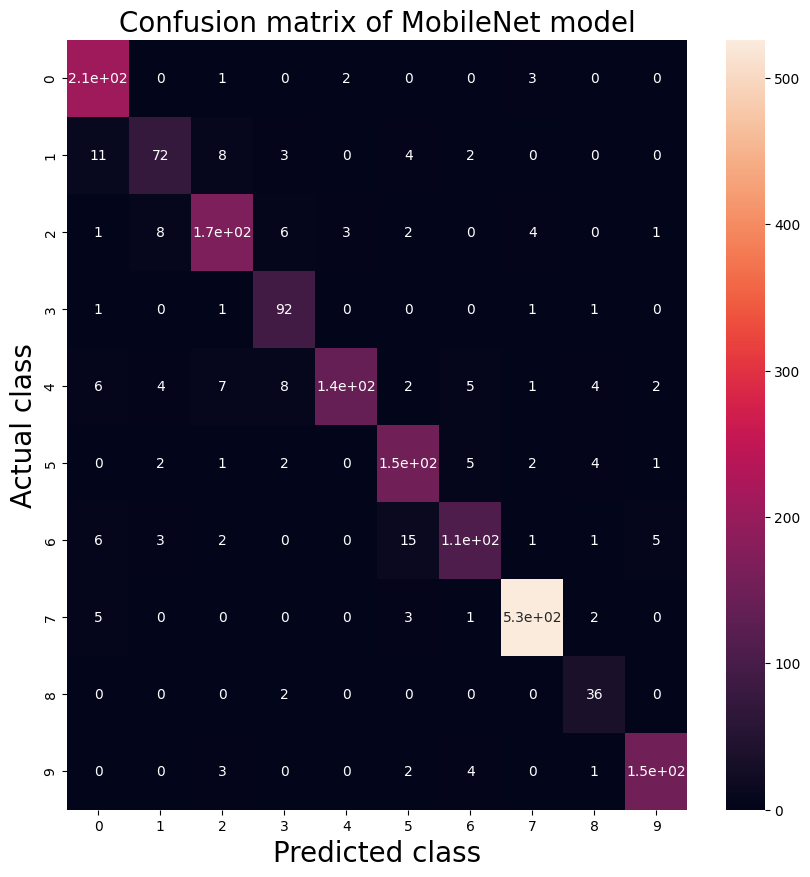

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,annot_kws={'size':10})
plt.xlabel("Predicted class",fontsize=20)
plt.ylabel("Actual class",fontsize=20)
plt.title("Confusion matrix of MobileNet model",fontsize=20)
plt.show()

each row -> Actual class(ground truth)
each column -> predicted class
diagonal values -> correctly classified samples.
off-diagonal values -> misclassification